In [1]:
#Basics
import os
import numpy as np
import pandas as pd 

In [2]:
# Stats
import scipy.stats as stats # For stats
import statsmodels.api as sm # For ANOVA
from statsmodels.formula.api import ols # For ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd # post-hoc analyses for anova's main effects
import statsmodels.formula.api as smf #LME

In [3]:
#Visualizations
import matplotlib.pyplot as plt
import matplotlib.colors as mc   # For darkening / lightning a color pallete that isnt rgb
import seaborn as sns                         
import matplotlib.ticker as ticker
import datetime  # For dating  exported results 

#### Paths:

In [4]:
path_main = os.path.split(os.getcwd())[0] # one step up from where this code lives 
path_main

'/mnt/cup/labs/gomez/data/deaf/Manuscripts_Grants/Category_Manu_panels/Data_and_Code'

In [5]:
path_results = path_main + "/Notebook_Outputs/Outputs_Fig5A/" # Where we want the stats and plots to be saved 

# Create the folder (should not bother existing folder if it already exists)
os.makedirs(path_results, exist_ok=True)

tablename = 'Nverts_Tth3.csv'

#### Load Data: 

In [6]:
table_Nverts = pd.read_csv(path_main+ '/Data/'+ tablename)
table_Nverts

,Sub,Group,Surface,Contrast,hemi,Nverts
0,DB11,D,Lateral,house-v-all,lh,983
1,DB22,D,Lateral,house-v-all,lh,243
2,DB44,D,Lateral,house-v-all,lh,1092
3,DB00,D,Lateral,house-v-all,lh,912
4,DC44,D,Lateral,house-v-all,lh,801
...,...,...,...,...,...,...
391,CG11,C,Ventral_NoATL,hand-v-nonlimb,rh,133
392,CW77,C,Ventral_NoATL,hand-v-nonlimb,rh,174
393,CM88,C,Ventral_NoATL,hand-v-nonlimb,rh,178
394,CA88,C,Ventral_NoATL,hand-v-nonlimb,rh,243


In [7]:
# Define Group order to be consistent throughout 
group_order = ['C','H','D']
group_names = ["HC","HE","DE"]

# Define color pallate
custom_palette = ['cornflowerblue', '#ffcd8e', '#ff80ff']# Define your custom color palette with three colors

# Convert custom pallete to rgb for easier manipulations (darker/lighter)
custom_palette_rgb= np.empty((3, 3), dtype=float)
for c,coli in enumerate(custom_palette):
    custom_palette_rgb[c,:] = mc.to_rgb(coli) 
    del coli, c

#### small helper function to allow us to both print and save out our stats results: 

In [8]:
def log_print(message, file_object):
    print(message)              # Prints to command line
    print(message, file=file_object) # Prints to text file

# Compute Lateralization Effects

In [9]:
lh_data = table_Nverts[(table_Nverts['hemi'] =='lh')]
rh_data = table_Nverts[(table_Nverts['hemi'] =='rh')]

# merge to make bilateral df with ratio column
bilateral_df =  pd.merge(lh_data, rh_data, on=['Sub', 'Group','Surface','Contrast'], suffixes=("_lh", "_rh"))
bilateral_df['L_LplusR']  = bilateral_df["Nverts_lh"] /( bilateral_df["Nverts_lh"] + bilateral_df["Nverts_rh"])    
bilateral_df.head(15)

,Sub,Group,Surface,Contrast,hemi_lh,Nverts_lh,hemi_rh,Nverts_rh,L_LplusR
0,DB11,D,Lateral,house-v-all,lh,983,rh,1095,0.473051
1,DB22,D,Lateral,house-v-all,lh,243,rh,788,0.235694
2,DB44,D,Lateral,house-v-all,lh,1092,rh,1720,0.388336
3,DB00,D,Lateral,house-v-all,lh,912,rh,1356,0.402116
4,DC44,D,Lateral,house-v-all,lh,801,rh,1488,0.349934
5,DC88,D,Lateral,house-v-all,lh,406,rh,823,0.330350
6,DC22,D,Lateral,house-v-all,lh,354,rh,876,0.287805
7,DS77,D,Lateral,house-v-all,lh,51,rh,74,0.408000
8,DR11,D,Lateral,house-v-all,lh,400,rh,504,0.442478
9,DE44,D,Lateral,house-v-all,lh,1555,rh,1470,0.514050


In [10]:
depmes = 'L_LplusR'

### Plot Raw LR Bias (before bootstrapping) 
* separate subplot for each surf and contrast 

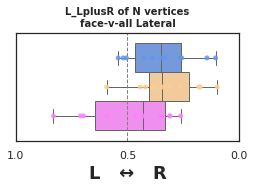

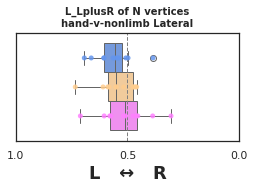

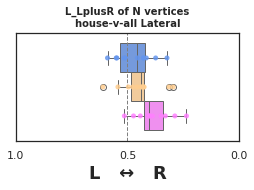

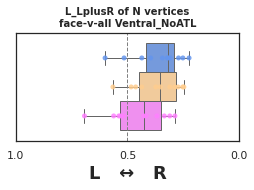

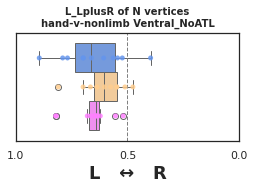

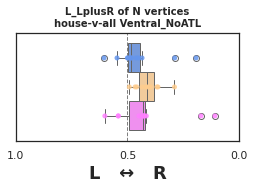

In [11]:
contrast_limiter =  ['face-v-all','hand-v-nonlimb', 'house-v-all']#, 'word-v-all']#np.unique(table_Nverts.Contrast) #['house-v-all','face-v-all','hand-v-nonlimb']#,'animate-v-inanimate']
# contrast_names = ['Face','Hand','Place']#,'Animate'] cats#
        
for s, surf in enumerate(np.unique(table_Nverts.Surface)):
    for c, cat in enumerate(contrast_limiter):


            plt.figure(figsize=(4,2)) 
            sns.set_theme(style="white", palette="pastel")

            bilat_subset  = bilateral_df[(bilateral_df['Surface'] ==surf) & (bilateral_df['Contrast'] ==cat) ]    

            order_list = np.unique(bilat_subset['Surface']) # Unique function also sorts!

            ax=sns.boxplot(bilat_subset,x=depmes,y='Surface',order = order_list, #width=.5,
                        hue="Group",hue_order=[ "C", "H", "D"], orient='h',dodge=True,palette=custom_palette)#, inner="stick", palette="Blues",cut=0)#, hue="conditionName")#, palette=my_palette[0:3])#, inner="points")
            sns.stripplot(bilat_subset,x=depmes,y='Surface',order = order_list,
                        hue="Group",hue_order=[ "C", "H", "D"], orient='h',
                          dodge=True, jitter=False, s=5,alpha=0.85,palette=custom_palette)

            plt.title( depmes + ' of N vertices' +'\n' + cat+' ' + surf, fontweight ='bold', fontsize = 10)
            plt.xlabel('L   \u2194   R', fontweight ='bold', fontsize = 18)
            plt.ylabel('', fontweight ='bold', fontsize = 15)

            # Invert the x-axis
            plt.gca().invert_xaxis()

            ax.get_legend().set_visible(False)
            plt.yticks([], [])

            plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1)
            plt.xticks([1,0.5,0])
            plt.show()

## Bootstrap LR Ratio

#### Setup: 

In [12]:
# Initialize generator for consistency
rng = np.random.default_rng(12)
    
# Define parameters: 
n_subs = 11;
n_it = 1000; # number of bootstrapping iterations
cats = np.unique(table_Nverts.Contrast) #['Faces','Bodies','Scenes'] ['face-v-all','hand-v-nonlimb', 'house-v-all','animate-v-inanimate'] #
srfcs = np.unique(table_Nverts.Surface) #['Faces','Bodies','Scenes']


#### Define function to calculate cohen's d within each iteration: 

In [13]:
# Compute Cohen's d per iteration assuming equal sample sizes:

def cohens_d(df_boots_diff_LRatio, groupname_1, groupname_2):

    # Calculate the simplified pooled standard deviation (equal sample sizes)
    pooled_std = np.sqrt((df_boots_diff_LRatio[groupname_1+'_std']**2 + df_boots_diff_LRatio[groupname_2+'_std']**2) / 2)
    
    # Compute Cohen's d for every iteration
    cohens_d_per_it = df_boots_diff_LRatio[groupname_1+groupname_2] / pooled_std
    
    return cohens_d_per_it

#### Initialize temporary variables to hold data across iterations: 


In [14]:
boot_means   =  np.full((len(group_order), len(cats), len(srfcs),n_it ), np.nan)
boot_medians =  np.full((len(group_order), len(cats), len(srfcs),n_it ), np.nan)
boot_std     =  np.full((len(group_order), len(cats), len(srfcs),n_it ), np.nan)

# Initialize dataframe to hold all data
column_names = ['group','surface','contrast', 'iteration','mean','median','std']
df_boots_LRatio = pd.DataFrame(columns=column_names)

### BOOTSTRAP!


In [15]:
for g, grp in enumerate(group_order):
    for c, cat in enumerate(cats):
        for s, surf in enumerate(srfcs):
            
            df_subset = bilateral_df[(bilateral_df['Group']==grp) & (bilateral_df['Contrast']==cat) & 
                                     (bilateral_df['Surface']==surf)]

            for it in range(n_it): # iterations for bootstrapping
                rand_subs = rng.integers(0, n_subs, size=n_subs) 
                it_data = df_subset.iloc[rand_subs]
    #             print(it_data[0:3]) # Sanity check 
    
                Bias_it = it_data['L_LplusR'].to_numpy()
            
                boot_means[g,c,s,it]   = np.round(np.mean(Bias_it),5)
                boot_medians[g,c,s,it] = np.round(np.median(Bias_it),5)
                boot_std[g,c,s,it]     = np.round(np.std(Bias_it),5)    # We'll use this to calculate cohen's d per iteration

                del rand_subs

            # Make dataframe for this group, category, across all iterations. 
            # Then add to large one (df_boots) and delete temp. 
            data4df = {'group': [grp]*n_it, 'surface': [surf]*n_it, #'hemi': [hem]*n_it, 
                       'contrast': [cat]*n_it, 'iteration': (range(1,n_it+1)), 
                       'mean': boot_means[g,c,s,:] , 'median': boot_medians[g,c,s,:] , 'std': boot_std[g,c,s,:]}
            df_boot_temp = pd.DataFrame(data4df)
            df_boots_LRatio = pd.concat([df_boots_LRatio,df_boot_temp])

            del df_subset, it_data,Bias_it, data4df, df_boot_temp
del boot_means, boot_medians, boot_std

# Export dataframe with all iterations to csv file:
df_boots_LRatio.to_csv(path_results +'Bootstrapping_' + depmes +'_'+ str(np.datetime64('today')) +'.csv', index=False)


## Compute Stats for group differences across iterations
* Compute group difference per iteration
* Long to wide format using Pivot : Have a separate column for each group pair copmarison

In [16]:
# Create a summary table
df_boots_diff_LRatio = df_boots_LRatio.pivot(index=['surface','contrast','iteration' ], columns='group', values='mean')
df_boots_diff_LRatio = df_boots_diff_LRatio.reset_index()

# # Calculate the difference in means
df_boots_diff_LRatio['DC'] = df_boots_diff_LRatio['D'] - df_boots_diff_LRatio['C']
df_boots_diff_LRatio['HC'] = df_boots_diff_LRatio['H'] - df_boots_diff_LRatio['C']
df_boots_diff_LRatio['DH'] = df_boots_diff_LRatio['D'] - df_boots_diff_LRatio['H']

# add to df also the std per iteration (within group, not group differences)
df_boots_diff_LRatio_std = df_boots_LRatio.pivot(index=['surface','contrast','iteration' ], columns='group', values='std')
df_boots_diff_LRatio_std = df_boots_diff_LRatio_std.reset_index()
df_boots_diff_LRatio_std = df_boots_diff_LRatio_std.rename(columns={c: c + '_std' for c in group_order})
df_boots_diff_LRatio_std

# Merge to a single df that holds for every iteration: 
# (1) group mean per it (2) group differences per it (3) within-group std per it
df_boots_diff_LRatio = pd.merge(df_boots_diff_LRatio,df_boots_diff_LRatio_std,on=['surface','contrast','iteration' ])#,suffixes=('_DC', '_HC'))
df_boots_diff_LRatio.head(5)

group,surface,contrast,iteration,C,D,H,DC,HC,DH,C_std,D_std,H_std
0,Lateral,face-v-all,1,0.37252,0.36733,0.31139,-0.00519,-0.06113,0.05594,0.11182,0.11637,0.14496
1,Lateral,face-v-all,2,0.34830,0.45711,0.38548,0.10881,0.03718,0.07163,0.11619,0.13712,0.13654
2,Lateral,face-v-all,3,0.30988,0.41758,0.36419,0.10770,0.05431,0.05339,0.15854,0.10423,0.14032
3,Lateral,face-v-all,4,0.31914,0.51244,0.30891,0.19330,-0.01023,0.20353,0.12175,0.19042,0.20171
4,Lateral,face-v-all,5,0.37605,0.42509,0.37380,0.04904,-0.00225,0.05129,0.10260,0.15546,0.10089


### Calculate cohen's d per iteration 
* Effect size for group difference per iteration 
* Add column per group pair comparison (e.g. Cohen's d for DS vs Controls)

In [17]:
# Compute Effect size for group difference *per iteration* using previously defined function
# Add column per group pair comparison (e.g. Cohen's d for DS vs Controls)
# Noe we have a cohen's d value for each iteration.
                                        
df_boots_diff_LRatio['DC_cohens_d'] = cohens_d(df_boots_diff_LRatio, 'D', 'C')
df_boots_diff_LRatio['HC_cohens_d'] = cohens_d(df_boots_diff_LRatio, 'H', 'C')
df_boots_diff_LRatio['DH_cohens_d'] = cohens_d(df_boots_diff_LRatio, 'D', 'H')
df_boots_diff_LRatio.head(4)

group,surface,contrast,iteration,C,D,H,DC,HC,DH,C_std,D_std,H_std,DC_cohens_d,HC_cohens_d,DH_cohens_d
0,Lateral,face-v-all,1,0.37252,0.36733,0.31139,-0.00519,-0.06113,0.05594,0.11182,0.11637,0.14496,-0.045479,-0.472211,0.425578
1,Lateral,face-v-all,2,0.34830,0.45711,0.38548,0.10881,0.03718,0.07163,0.11619,0.13712,0.13654,0.856188,0.293278,0.523495
2,Lateral,face-v-all,3,0.30988,0.41758,0.36419,0.10770,0.05431,0.05339,0.15854,0.10423,0.14032,0.802762,0.362774,0.431960
3,Lateral,face-v-all,4,0.31914,0.51244,0.30891,0.19330,-0.01023,0.20353,0.12175,0.19042,0.20171,1.209510,-0.061405,1.037644


# Compare each group to the null hypothesis (ratio=0.5) - is there a LR Bias ? 
* The previous part adressed the question - are there group differences in LR Ratio?
* Now we want to quantify within each group, is there a significant LR bias?
* So we now quantify a different metric: Comparing the LR bias to the null hypothesis whereby [Ratio == 0.5]

In [18]:
def stats_LR_ratio_vs_null(df_boots_diff_LRatio, cats, group_name, depmes):
        
    df_stats = pd.DataFrame(columns=['cat', 'surf', 'group','pval', 'CI_low', 'CI_hi', 'median','std','cohens_d'])

    # Plot histogram of bootstraps with overlayed 'observed mean'
    for c, cat in enumerate(cats):
        for s, surf in enumerate(np.unique(df_boots_diff_LRatio.surface)):

                df_boot_G = df_boots_diff_LRatio[(df_boots_diff_LRatio['contrast']==cat) &
                                 (df_boots_diff_LRatio['surface']==surf)]
                
                compare_to = 0.5 # Our Null Hypothesis is that the Ratio = 0.5
                proportion_above = sum(df_boot_G[group_name]>=compare_to)/n_it
                proportion_below = sum(df_boot_G[group_name]<=compare_to)/n_it
                pval=2*min(proportion_above,proportion_below) # DOUBLE the pvalue FOR TWO-SIDED TEST

                quant_lo = (np.round(np.quantile(df_boot_G[group_name], 0.025),3))
                quant_hi = (np.round(np.quantile(df_boot_G[group_name], 0.975),3))
                quant_mid = (np.round(np.quantile(df_boot_G[group_name], 0.50),3))
                g_std = df_boot_G[group_name].std()
                
                cohens_d = np.mean((df_boot_G[group_name]-compare_to) / (df_boot_G[group_name+'_std'])) # When comparing to a scalar we don't need to worry about pooled variance

                # Save Stats
                newrow= pd.DataFrame([{'cat': cat, 'surf': surf, 'group': group_name,
                                     'pval':np.round(pval,8), 'CI_low':quant_lo, 'CI_hi':quant_hi,
                                       'median':quant_mid,'std':np.round(g_std,3), 
                                       'cohens_d':np.round(cohens_d,2)}])
                df_stats=pd.concat([df_stats,newrow])

    return df_stats

(run the function per group, and merge results to a single df)

In [19]:
df_stats_null_D =  stats_LR_ratio_vs_null(df_boots_diff_LRatio, cats, 'D',depmes)
df_stats_null_H =  stats_LR_ratio_vs_null(df_boots_diff_LRatio, cats, 'H',depmes)
df_stats_null_C =  stats_LR_ratio_vs_null(df_boots_diff_LRatio, cats, 'C',depmes)

# Merge the DFs keeping informative column names: 
df_stats_null_LR = pd.merge(df_stats_null_D,df_stats_null_H,on=['cat','surf'],suffixes=('_D', '_H')) #Merge HS and DS groups
# Add C suffix to stats colums
df_stats_null_C = df_stats_null_C.rename(columns={c: c + '_C' for c in ['group','pval', 'CI_low', 'CI_hi', 'median','cohens_d']})
df_stats_null_LR = pd.merge(df_stats_null_LR,df_stats_null_C,on=['cat','surf']) # Merge C group as well 

# Export results to csv file 
df_stats_null_LR.to_csv(path_results +'All_Bootstrapped_' + depmes + '_vs_ZeroPointFive.csv', index=False)
df_stats_null_LR.head(5)

,cat,surf,group_D,pval_D,CI_low_D,CI_hi_D,median_D,std_D,cohens_d_D,group_H,...,median_H,std_H,cohens_d_H,group_C,pval_C,CI_low_C,CI_hi_C,median_C,std,cohens_d_C
0,face-v-all,Lateral,D,0.750,0.376,0.595,0.482,0.057,-0.16,H,...,0.328,0.040,-1.43,C,0.000,0.263,0.424,0.347,0.041,-1.19
1,face-v-all,Ventral_NoATL,D,0.184,0.385,0.522,0.454,0.035,-0.45,H,...,0.366,0.032,-1.49,C,0.002,0.301,0.437,0.362,0.034,-1.50
2,hand-v-nonlimb,Lateral,D,0.818,0.445,0.571,0.507,0.032,0.09,H,...,0.544,0.024,0.61,C,0.010,0.513,0.609,0.561,0.024,0.90
3,hand-v-nonlimb,Ventral_NoATL,D,0.000,0.608,0.712,0.657,0.027,2.06,H,...,0.609,0.026,1.35,C,0.000,0.575,0.728,0.649,0.040,1.23
4,house-v-all,Lateral,D,0.000,0.338,0.427,0.386,0.023,-1.66,H,...,0.447,0.025,-0.72,C,0.156,0.420,0.511,0.467,0.023,-0.45


# PLOT KDEs 
* Function to plot the distributions of L/R Bias in all experimental groups
* Comparing all groups to the null /no bias hypothesis
* Choose: with or without stats on each panel 
* Choose: square (0) or Wide (1) panels

In [20]:
def plot_KDE_LR(path_resultsplotspath,df_boots_LRatio, cats, group_order, custom_palette, depmes, wide =1, wstats = []):

    # Function to plot the distributions of L/R Bias in all experimental groups
    # Plot KDE of bootstraped LR Ratio
    
    for c, cat in enumerate(cats):
        for s, surf in enumerate(np.unique(table_Nverts.Surface)):

            if wide ==0:
                fig = plt.subplots(figsize=(4,3))
                fsize=''
            else:
                fig = plt.subplots(figsize=(4,2))
                fsize='wide_'

            print(surf + ', '+cat)

            for g, grp in enumerate(group_order):

                df_boot_G = df_boots_LRatio[(df_boots_LRatio['group']==grp) & (df_boots_LRatio['contrast']==cat) &
                                     (df_boots_LRatio['surface']==surf) ]

                ax = sns.kdeplot(df_boot_G['mean'], color=custom_palette[g],fill=True,alpha=0.5,linewidth=3)

                plt.xlabel('L   \u2194   R', fontweight ='bold', fontsize = 20)
                plt.ylabel('', fontweight ='bold', fontsize = 15)

                # Invert the x-axis
                plt.gca().invert_xaxis()

                # Fine tune asthetics:
                plt.xticks(fontsize = 22)
                plt.yticks([])#fontsize = 20)

                plt.locator_params(axis='x', nbins=3)
                plt.locator_params(axis='y', nbins=2)
            

            del df_boot_G

            # Reference Line at 0.5
            plt.axvline(x=0.5, color='k', linestyle='--', linewidth=2)
            plt.xticks([int(1),0.5,0])
            
            # Add stats on figure in a legible manner: 
                
            if isinstance(wstats, pd.DataFrame) and not wstats.empty: # THIS COMPARES TO 0.5
                df_stats_subset = wstats[ (wstats['cat']==cat) &(wstats['surf']==surf) ]
                cohens_D = np.array(df_stats_subset['cohens_d_D'])
                p_D = np.array(df_stats_subset['pval_D'])[0]
                cohens_H = np.array(df_stats_subset['cohens_d_H'])
                p_H = np.array(df_stats_subset['pval_H'])[0]
                cohens_C = np.array(df_stats_subset['cohens_d_C'])
                p_C = np.array(df_stats_subset['pval_C'])[0]

                if p_D<0.001:
                    stats_text_D = (f'Cohen\'s d (DS)= {cohens_D[0]:.1f}    p<0.001 **')
                elif p_D<0.050:
                    stats_text_D = (f'Cohen\'s d (DS)= {cohens_D[0]:.1f}    p={p_D:.3f} *')
                elif p_D<0.12:
                    stats_text_D = (f'Cohen\'s d (DS)= {cohens_D[0]:.1f}    p={p_D:.3f}')
                else:
                    stats_text_D = (f'Cohen\'s d (DS)= {cohens_D[0]:.1f}')

                if p_H<0.001:
                    stats_text_H = (f'Cohen\'s d (HS)= {cohens_H[0]:.1f}    p<0.001 **')
                elif p_H<0.050:
                    stats_text_H = (f'Cohen\'s d (HS)= {cohens_H[0]:.1f}    p={p_H:.3f} *')
                elif p_H<0.12:
                    stats_text_H = (f'Cohen\'s d (HS)= {cohens_H[0]:.1f}    p={p_H:.3f}')
                else:
                    stats_text_H = (f'Cohen\'s d (HS)= {cohens_H[0]:.1f}')
                    
                if p_C<0.001:
                    stats_text_C = (f'Cohen\'s d (C)= {cohens_C[0]:.1f}      p<0.001 **')
                elif p_C<0.050:
                    stats_text_C = (f'Cohen\'s d (C)= {cohens_C[0]:.1f}      p={p_C:.3f} *')
                elif p_C<0.12: 
                    stats_text_C = (f'Cohen\'s d (C)= {cohens_C[0]:.1f}      p={p_C:.3f}')
                else:
                    stats_text_C = (f'Cohen\'s d (C)= {cohens_C[0]:.1f}')

                # Text location varies if the plot is square or wide    
                if wide ==0:
                    add_range_ylim = 0.35
                    ytxtmax = 0.96
                    yjump = 0.08
                else:
                    add_range_ylim = 0.6
                    ytxtmax = 0.96
                    yjump = 0.13
                
                ymin, ymax = ax.get_ylim()
                y_range = ymax - ymin
                new_ymax = ymax + add_range_ylim * y_range  # add some % of the range
                ax.set_ylim(ymin, new_ymax)

                # text on figure: 
                ax.text(0.02, ytxtmax, stats_text_D,   
                transform=ax.transAxes,ha='left',va='top',   #  alignment                   
                fontsize=10,color=custom_palette_rgb[2]*0.7) #  font color to match group color, but darker shade

                ax.text(0.02, ytxtmax-yjump,stats_text_H, 
                transform=ax.transAxes,ha='left',va='top',
                fontsize=10,color=custom_palette_rgb[1]*0.7)
                
                ax.text(0.02,ytxtmax-2*yjump,stats_text_C, 
                transform=ax.transAxes,ha='left',va='top',                      
                fontsize=10,color=custom_palette_rgb[0]*0.7)

                surf=surf+'_stats' # so we don't overwrite the saved images if we want a version with and without stats

            plt.savefig(path_results+"Bootstrap_group_comparison_" +
            cat +'_' + surf + '_KDE_' + fsize +
            str(np.datetime64('today')) + ".png",format='png',dpi=300, bbox_inches='tight')

            plt.show()

Lateral, face-v-all


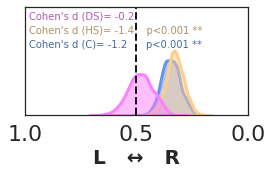

Ventral_NoATL, face-v-all


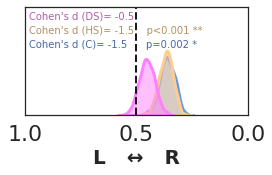

Lateral, hand-v-nonlimb


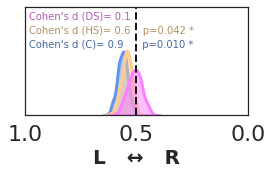

Ventral_NoATL, hand-v-nonlimb


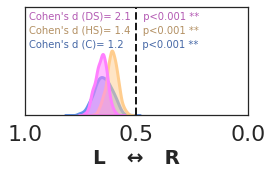

Lateral, house-v-all


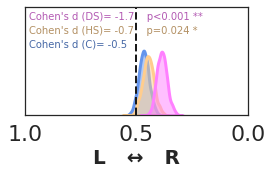

Ventral_NoATL, house-v-all


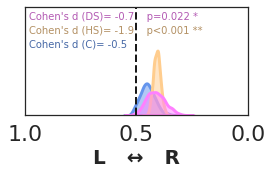

In [21]:
plot_KDE_LR(path_results,df_boots_LRatio, cats, group_order, custom_palette, depmes, wide =1, wstats = df_stats_null_LR)